# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


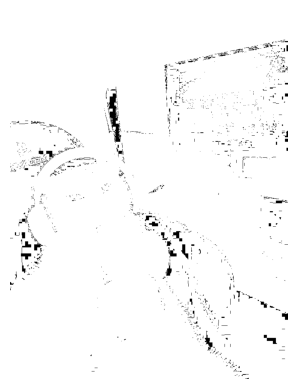

Threshold value: 50


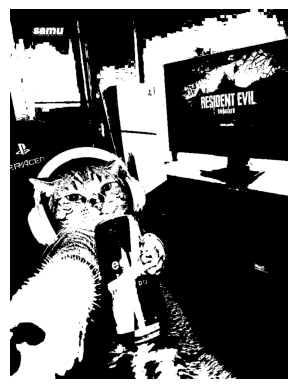

Threshold value: 100


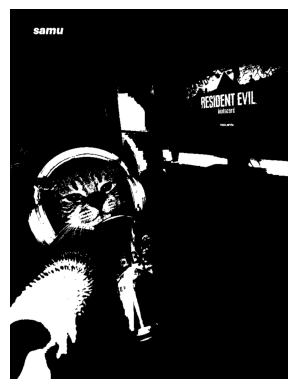

Threshold value: 150


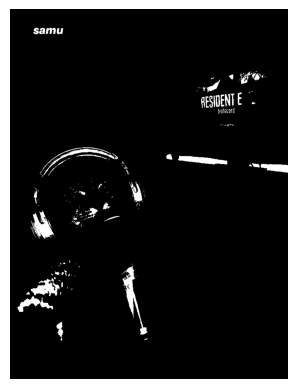

Threshold value: 200


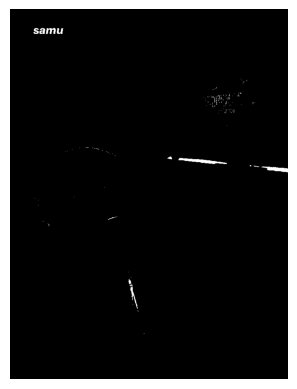

In [9]:
import cv2
import matplotlib.pyplot as plt

# Load an external image in grayscale
img = cv2.imread('images/imege1.jpg', cv2.IMREAD_GRAYSCALE)


threshold_values = [0, 50, 100, 150, 200]

for threshold_value in threshold_values:
    ret_thresh_value, thresh_img = cv2.threshold(
        img, threshold_value, 255, cv2.THRESH_BINARY
    )

    print(f"Threshold value: {threshold_value}")
    plt.imshow(thresh_img, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')
    plt.show()

Original Image:


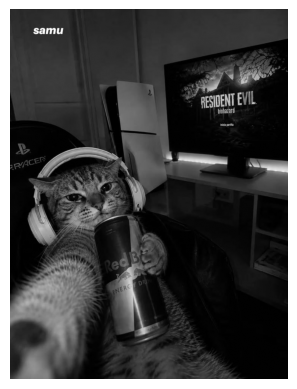

In [4]:
print("Original Image:")
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

## Histograms

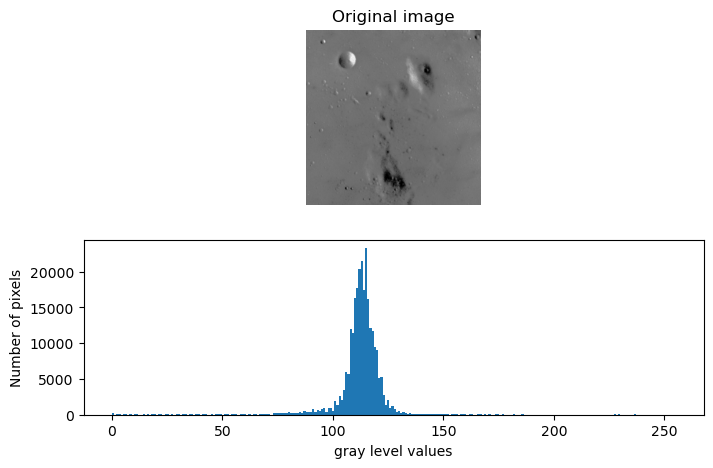

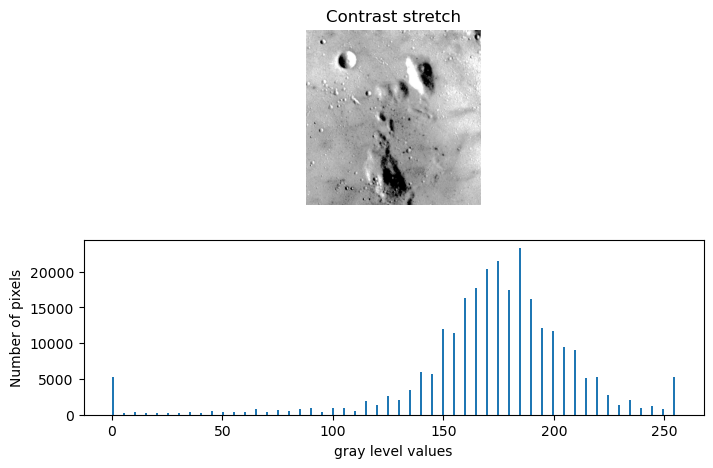

In [5]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


3rd percentile: 87.0, 80th percentile: 118.0


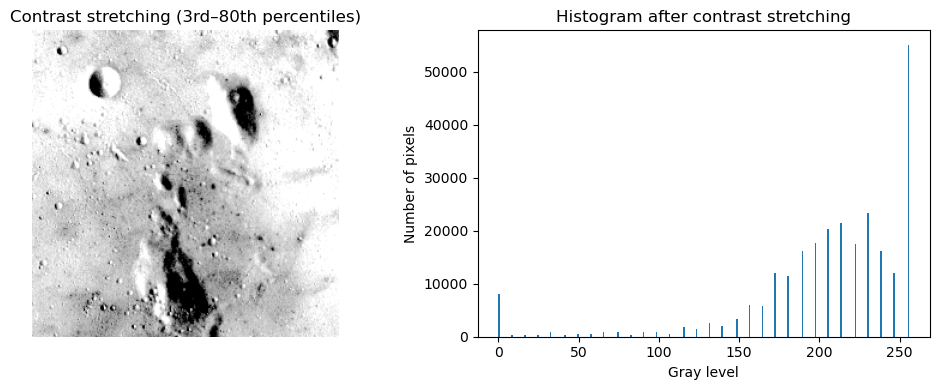

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure

moon = data.moon()
p3, p80 = np.percentile(moon, (3, 80))
moon_rescale = exposure.rescale_intensity(moon, in_range=(p3, p80))
print(f'3rd percentile: {p3}, 80th percentile: {p80}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(moon_rescale, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Contrast stretching (3rd–80th percentiles)')
axes[0].axis('off')
axes[1].hist(moon_rescale.ravel(), bins=256, range=(0, 256))
axes[1].set_title('Histogram after contrast stretching')
axes[1].set_xlabel('Gray level')
axes[1].set_ylabel('Number of pixels')
plt.tight_layout()
plt.show()

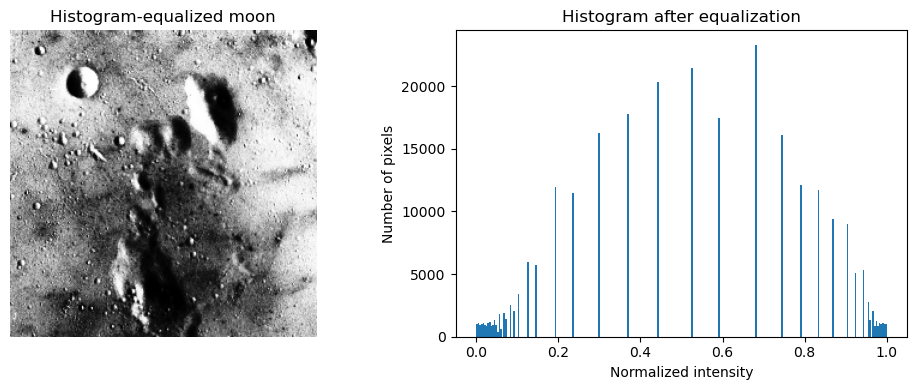

In [7]:
moon = data.moon()
moon_equalized = exposure.equalize_hist(moon)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(moon_equalized, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Histogram-equalized moon')
axes[0].axis('off')
axes[1].hist(moon_equalized.ravel(), bins=256, range=(0, 1))
axes[1].set_title('Histogram after equalization')
axes[1].set_xlabel('Normalized intensity')
axes[1].set_ylabel('Number of pixels')
plt.tight_layout()
plt.show()

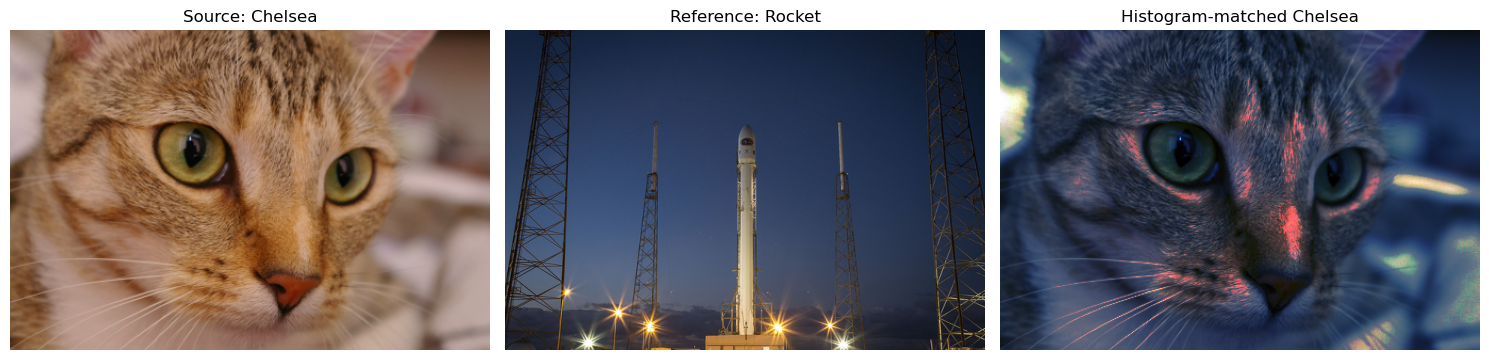

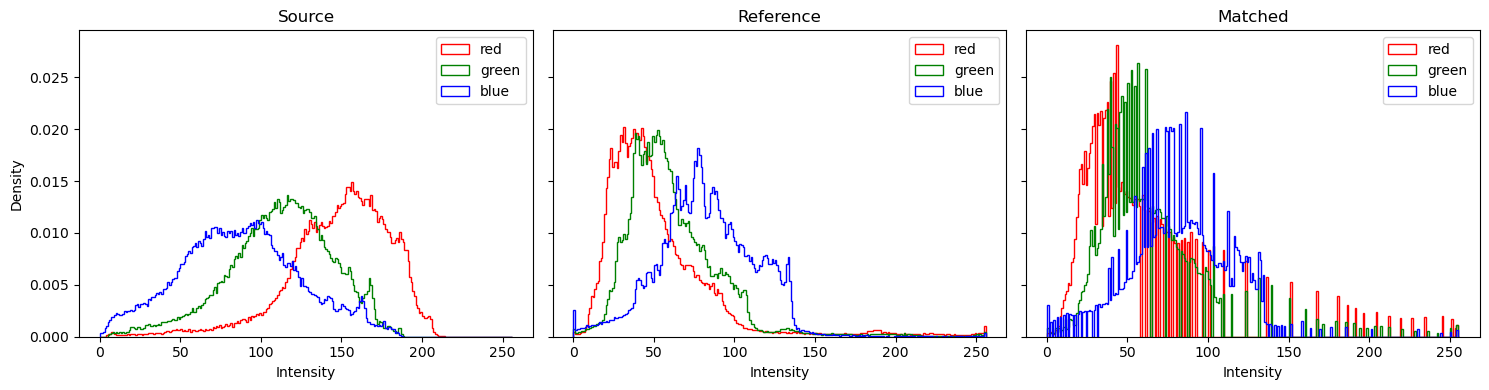

In [8]:
source = data.chelsea()
reference = data.rocket()
matched = exposure.match_histograms(source, reference, channel_axis=-1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, image, title in zip(
    axes,
    [source, reference, np.clip(matched, 0, 255).astype(np.uint8)],
    ['Source: Chelsea', 'Reference: Rocket', 'Histogram-matched Chelsea']
):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

# Compare normalized RGB histograms because image sizes differ.
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, image, title in zip(axes, [source, reference, matched],
                            ['Source', 'Reference', 'Matched']):
    for channel, color in enumerate(['red', 'green', 'blue']):
        ax.hist(image[..., channel].ravel(), bins=256, range=(0, 256),
                density=True, histtype='step', color=color, label=color)
    ax.set_title(title)
    ax.set_xlabel('Intensity')
    ax.legend()
axes[0].set_ylabel('Density')
plt.tight_layout()
plt.show()